**Problem Statement:**

1.  The main objective of the problem is to build the convolutional neural networks on the MNIST Handwritten digits dataset.


**Steps used in this Algorithm:-**

1.  Import all the necessary libraries

2.  Load the MNIST dataset

3.  Perform the Data preprocessing

4.  Build the CNN model

5.  Compile the model

6.  Train the model

7.  Evaluate the model

8.  Make predictions

9.  Visualize predictions

#### **Step 1: Import all the necessary libraries**

In [28]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   tensorflow.keras.datasets import mnist
from   tensorflow.keras.models   import Sequential
from   tensorflow.keras.layers   import Dense, Dropout,Conv2D, MaxPooling2D,Flatten
from   tensorflow.keras.utils    import to_categorical


#### **OBSERVATIONS:**

1.  Conv2D --------> Convolution 2D Images.

    (a.)  Here the convoluted output image is obtained by applying a kernel of certain size over an input image and then performing the dot product of each input image position with the corresponding position of the kernel. Thus it moves from top left to right row by row.

    (b.)  Relu activation function has been applied on the convoluted image to increase the non-linearity of the image.


2.  MaxPooling2D --------> Max Pooled Image

    (a.) This image is obtained after perfoming the operation of considering the pooled feature map of certain size over the input image of that size.

    (b.) Then maximum value is obtained from the input image row by row.

3. Flatten ------------->

    (a.)  Thus the pooled feature maps gets converted into the feature maps arranges in 1-d features.


3.  to_categorical ------->  

    (a.) It is used to convert the integer class labels into one hot encoded vectors.



#### **Step 2: Load the MNIST dataset**

In [29]:
#### divide the dataset into training and testing data
(X_train, Y_train),(X_test, Y_test)=mnist.load_data()

In [30]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [31]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [32]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing data  is:", X_test.shape)

Shape of the input training data is: (60000, 28, 28)
Shape of the input testing data  is: (10000, 28, 28)


#### **OBSERVATIONS:**

1.  The above dataframe explains about the input training and testing images.

2.  There are a total of

    (a.)  60000 training images

    (b.)  28    image height

    (c.)  28    image width

3.  Similarly there are a total of

    (a.)  10000 testing images

    (b.)  28    image height

    (c.)  28    image width

In [33]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [34]:
Y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [35]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing data  is:", Y_test.shape)

Shape of the output training data is: (60000,)
Shape of the output testing data  is: (10000,)


##### **OBSERVATIONS:**

1.  There is a total of 1 dimensional array of 60000 output training data.

2.  There is a total of 1 dimensional array of 10000 output testing data.

#### **Step 3: Perform the Data preprocessing**

In [36]:
#### Shape of the input training and testing data before preprocessing
train = X_train.shape
test  = X_test.shape

print("Shape of the training data is:", train)
print("Shape of the testing data  is:", test)

Shape of the training data is: (60000, 28, 28)
Shape of the testing data  is: (10000, 28, 28)


#### **OBSERVATIONS:**

1.  Initially, the input training and testing data is in the form of

  (No of training images, height, width) which is not the appropriate form of the input accepted by CNN

2.  So reshaping is done to convert the input into such a format that can be accepted by CNN.

In [37]:
#### Reshape the input image to make it a suitable input for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test  = X_test.reshape(-1,28,28,1)

In [38]:
X_train

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [39]:
X_test

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [40]:
#### Shape of the input training and testing data after data preprocessing
train=X_train.shape
test=X_test.shape

print("Shape of the input training data after preprocessing is:", train)
print("Shape of the input testing  data after preprocessing is:", test)

Shape of the input training data after preprocessing is: (60000, 28, 28, 1)
Shape of the input testing  data after preprocessing is: (10000, 28, 28, 1)


#### **OBSERVATIONS:**

1.  The input data of the form(No of Images,height,width) is converted in the form(No of images,height,width,channel).

2.  The channel dimension has been added in the input layer to make it a suitable input for the CNN model.

In [41]:
#### Normalizing the pixel values
X_train = X_train/255.0

X_test  = X_test/255.0

In [42]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [43]:
X_test

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

#### **OBSERVATIONS:**

1.  Every pixel value is in the form of 0 to 255.

2.  Each pixel value is divided by 255.0 so as to normalize the pixel value.

3.  Normalization on the pixel values is done so that

    (a.)  It can provide better numerical stability

    (b.)  The activation functions can work properly

    (c.)  It can perform the faster training.



In [44]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [45]:
#### convert each input label into one hot encoded vectors
Y_train = to_categorical(Y_train, num_classes=10)

Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

#### **OBSERVATIONS:**

1.  to_categorical is used to consider each integer and convert it into one hot encoded form.

2.  It considers each digit and converts it into one hot encoded form of the size 10.

3.  This is done as the model cannot work with the integers directly. The model learns by comparing the probabilities of different classes, so it is converted into one hot encoded form.

In [46]:
Y_test = to_categorical(Y_test, num_classes=10)

Y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

#### **Step 4: Build the CNN model**

In [47]:
#### build the model
model = Sequential([
    #### build the first layer of Convolutional neural networks
    Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    #### perform MaxPooling on the convoluted layer
    MaxPooling2D(pool_size=(2,2))                                             ,

    #### build the second layer of Convolutional Neural Networks
    Conv2D(filters=64,kernel_size=(3,3),activation='relu')                    ,
    #### perform Max Pooling on the convoluted layer
    MaxPooling2D(pool_size=(2,2))                                             ,

    #### perform the flattening on the pooled feature maps
    Flatten()                                                                 ,

   #### construct the dense connected neural network
    Dense(128, activation='relu')                                             ,
   #### Add the Dropout layer to reduce overfitting
    Dropout(0.5)                                                              ,

    #### construct the output layer with 10 neurons
    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### **OBSERVATIONS:**

1.  The cnn model is created with the following steps :----   

    (a.)  The first layer of convolutional neural networks is made

          (i) with the input shape as (28,28,1). As a Gray scale image, it has 1 channel, 28 height pixel, 28 weight pixel is there.

          (ii)  Now Relu activation function has been applied to increase the non-linearity of the image.

          (iii) The convolution operation has been applied by passing the input image over the kernel size of 3*3 to extract all the important features from the images.

          (iv)  Then 32 feature maps has been fomed in the first layer

          (v)  Then the pooled feature window of size 2*2 has been applied over the convoluted input image to obtain the pooled feature map.


    (b.)  The second layer of convolutional neural networks is made

          (i)  Now Relu activation function has been applied over the image to increase the non-linearity of the image.

          (iii) The convolution operation has been applied by passing the input image over the kernel size of 3*3 to extract all the important features from the images.

          (iv)  Then 64 feature maps has been fomed in the first layer

          (v)  Then the pooled feature window of size 2*2 has been applied over the convoluted input image to obtain the pooled feature map.

    (c.) Flattening has been performed on the pooled feature maps to convert it into one dimensional vector.

    (d.)  This 1 d vector becomes the input for the dense connected layer where relu activation function has been applied on it to increase the non-linearity of the image and produce 128 neurons in the hidden layer

    (e.)  Dropout layer has been added over the dense connected layer to remove 50 % of the unwanted neurons and prevent the overfitting.

    (f.)  Then  the final output layer is constructed with 10 neurons and softmax activation fuction has been applied on it to get the probabilities of all the 10 classes.

#### **Step 5: Compile the model**

In [48]:
#### Compile the model
model.compile(
    optimizer = 'adam'                                    ,
    loss      = 'categorical_crossentropy'                ,
    metrics   = ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been made ready for the training using the followig parameters :---   

    (a.)  optimizer = 'adam' . It is an optimizer that updates the weights during the backpropogation

    (b.)   loss = 'categorical_crossentropy'. It is used for solving multi class classification problem

    (c.)   metrics = ['accuracy']. It is used to evaluate the performance of the model.

#### **Step 6: Train the model**

In [49]:
#### Train the model
history = model.fit(
    X_train                                                 ,
    Y_train                                                 ,
    batch_size         = 128                                ,
    epochs             = 10                                 ,
    validation_split   = 0.1                                ,
    verbose           = 1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 108ms/step - accuracy: 0.9037 - loss: 0.3153 - val_accuracy: 0.9792 - val_loss: 0.0677
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9696 - loss: 0.1013 - val_accuracy: 0.9855 - val_loss: 0.0474
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9772 - loss: 0.0746 - val_accuracy: 0.9888 - val_loss: 0.0394
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9823 - loss: 0.0607 - val_accuracy: 0.9883 - val_loss: 0.0359
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9845 - loss: 0.0522 - val_accuracy: 0.9887 - val_loss: 0.0385
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9908 - val_loss: 0.0334
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9878 - loss: 0.0401 - val_accuracy: 0.9910 - val_loss: 0.0292
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9895 - loss: 0.0336 -

#### **OBSERVATIONS:**

1.  The model has been trained with the following parameters:---

      (a.)  X_train Y_train --------->  Training data

      (b.)  epochs = 10  ---------->   Total iterations needed to train the model

      (c.)  batch_size = 128 -------->   128 samples are taken at once to train the model

      (d.)  validation_split = 0.1 ------>  10 % of the data is meant for validation

      (e.)  verbose = 1 --------------->  information printed during the model training.

  2. After the model training , we can see that the training and validation training of the model has increased but the loss and validation loss of the model has reduced.

#### **Step 7: Evaluate the model**

In [50]:
test_loss, test_acc = model.evaluate(X_test, Y_test,verbose=0)

print(f"Test loss is:{test_loss}")

print(f"Test Acc is:{test_acc}")

Test loss is:0.02468780428171158
Test Acc is:0.9919999837875366


#### **OBSERVATIONS:**

1. The test accuracy of the model is very high but the loss is very less. So the model is working fine.

#### **Step 8: Make predictions**

In [51]:
#### Perform the predictions on the test data
Y_pred = model.predict(X_test)
Y_pred

#### convert all the probabilities into the labels
Y_pred_data = np.argmax(Y_pred, axis=1)
Y_pred_data

Y_true = Y_pred_data

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


#### **OBSERVATIONS:**

1.  The ouput probabilities is predicted for the given input test data

2.  Then the probabilities is converted into the label and using argmax , it is used to get the index of the highest probability value.

#### **Step 9: Visualize predictions**

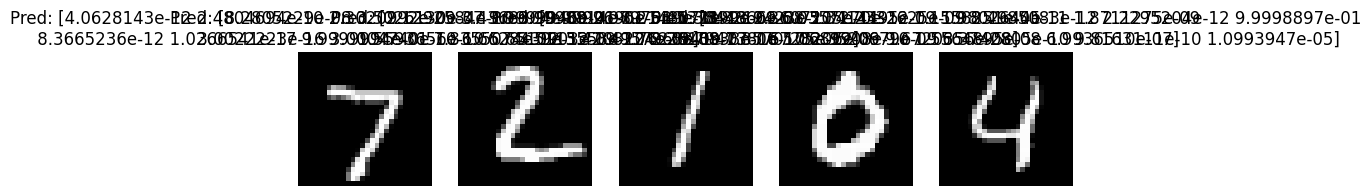

In [52]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {Y_pred[i]}")
    plt.axis('off')

plt.show()


#### **OBSERVATIONS:**

1.  The MNIST Handwritten digits data is predicted for the given input test data.